In [1]:
import scarf
import scarf.plotting as splt

scarf.set_verbosity("WARNING")
scarf.__version__

'1.0.0'

In [2]:
scarf.fetch_dataset(
    "tenx_8K_pbmc_citeseq",
    save_path="scarf_datasets",
    as_zarr=True,
)

In [3]:
ds = scarf.DataStore(
    "scarf_datasets/tenx_8K_pbmc_citeseq/data.zarr", default_assay="RNA", nthreads=4
)

In [4]:
ds

DataStore has 7549 (7865) cells with 2 assays: RNA ADT
   Cell metadata:
            'I', 'ids', 'names', 'ADT_nFeatures', 'RNA_percentMito', 
            'RNA_tSNE2', 'ADT_UMAP2', 'RNA_tSNE1', 'ADT_UMAP1', 'ADT_nCounts', 
            'RNA_percentRibo', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_cluster', 'RNA_leiden_cluster', 
            'ADT_leiden_cluster', 'RNA_UMAP2', 'RNA_UMAP1'
   RNA assay has 13550 (33538) features and following metadata:
            'I', 'ids', 'names', 'I__hvgs', 'nCells', 
            'dropOuts'
   ADT assay has 14 (17) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

In [5]:
ds.RNA.feats.head()

,I,ids,names,nCells,dropOuts,I__hvgs
0,False,ENSG00000243485,MIR1302-2HG,0,7865,False
1,False,ENSG00000237613,FAM138A,0,7865,False
2,False,ENSG00000186092,OR4F5,0,7865,False
3,False,ENSG00000238009,AL627309.1,12,7853,False
4,False,ENSG00000239945,AL627309.3,0,7865,False


In [6]:
ds.ADT.feats.head()

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1


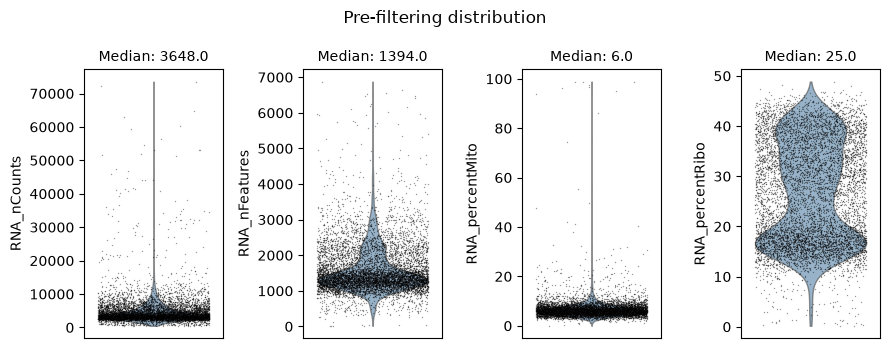

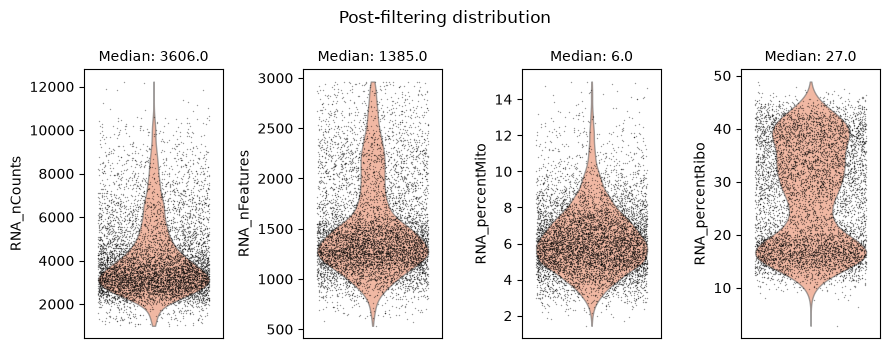

In [7]:
ds.auto_filter_cells()

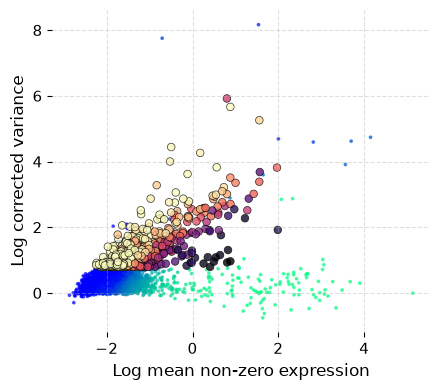

In [8]:
ds.mark_hvgs(min_cells=20, top_n=1000, min_mean=-3, max_mean=2, max_var=6)

ds.make_graph(feat_key="hvgs", k=21, dims=15, n_centroids=100)

ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True)

ds.run_leiden_clustering(resolution=1)

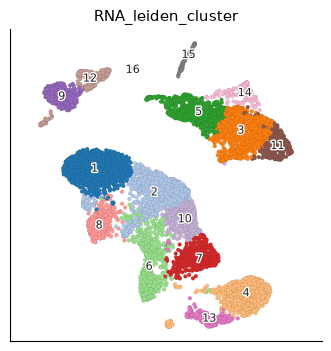

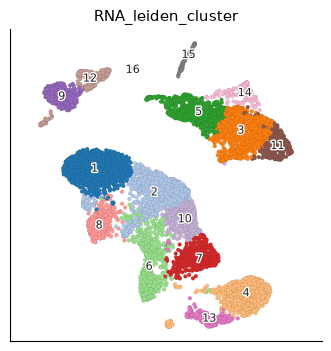

In [9]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="RNA_leiden_cluster",
    show=False,
).figure

In [10]:
ds.ADT.feats.head(n=ds.ADT.feats.N)

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1
5,True,CD16,CD16_TotalSeqB,7864,1
6,True,CD56,CD56_TotalSeqB,7864,1
7,True,CD19,CD19_TotalSeqB,7702,163
8,True,CD25,CD25_TotalSeqB,7861,4
9,True,CD45RA,CD45RA_TotalSeqB,7864,1


In [11]:
adt_names = ds.ADT.feats.to_pandas_dataframe(["names"])["names"]
adt_names

0               CD3_TotalSeqB
1               CD4_TotalSeqB
2              CD8a_TotalSeqB
3              CD14_TotalSeqB
4              CD15_TotalSeqB
5              CD16_TotalSeqB
6              CD56_TotalSeqB
7              CD19_TotalSeqB
8              CD25_TotalSeqB
9            CD45RA_TotalSeqB
10           CD45RO_TotalSeqB
11             PD-1_TotalSeqB
12            TIGIT_TotalSeqB
13            CD127_TotalSeqB
14    IgG2a_control_TotalSeqB
15     IgG1_control_TotalSeqB
16    IgG2b_control_TotalSeqB
Name: names, dtype: object

In [12]:
is_control = adt_names.str.contains("control").values
is_control

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True])

In [13]:
ds.ADT.feats.update_key(~is_control, "I")
ds.ADT.feats.head(n=ds.ADT.feats.N)

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1
5,True,CD16,CD16_TotalSeqB,7864,1
6,True,CD56,CD56_TotalSeqB,7864,1
7,True,CD19,CD19_TotalSeqB,7702,163
8,True,CD25,CD25_TotalSeqB,7861,4
9,True,CD45RA,CD45RA_TotalSeqB,7864,1


In [14]:
print(ds.ADT)
print(ds.ADT.normMethod.__name__)

ADTassay ADT with 14(17) features
norm_clr


In [15]:
ds.make_graph(from_assay="ADT", feat_key="I", k=21, dims=0, n_centroids=100)

In [16]:
ds.run_umap(from_assay="ADT", n_epochs=250, spread=5, min_dist=1, parallel=True)

ds.run_leiden_clustering(from_assay="ADT", resolution=1)

In [17]:
ds.cells.head()

,I,ids,names,RNA_percentMito,RNA_tSNE2,ADT_nFeatures,ADT_UMAP2,RNA_tSNE1,ADT_UMAP1,RNA_percentRibo,ADT_nCounts,RNA_nCounts,RNA_cluster,RNA_nFeatures,RNA_leiden_cluster,ADT_leiden_cluster,RNA_UMAP1,RNA_UMAP2
0,True,AAACCCAAGATTGTGA-1,AAACCCAAGATTGTGA-1,8.668831,-18.08830,17.0,-13.740351,-4.26865,-18.150482,15.259740,981.0,6160.0,4,2194.0,3,4,26.716892,15.183228
1,True,AAACCCACATCGGTTA-1,AAACCCACATCGGTTA-1,6.316103,-14.88920,17.0,-4.440004,5.02671,-13.933869,19.037688,1475.0,6713.0,4,2093.0,3,14,27.374599,11.789906
2,True,AAACCCAGTACCGCGT-1,AAACCCAGTACCGCGT-1,8.056090,-18.83030,17.0,-5.747980,-14.91320,-14.768224,16.002200,7149.0,3637.0,5,1518.0,3,4,16.271772,12.644808
3,True,AAACCCAGTATCGAAA-1,AAACCCAGTATCGAAA-1,9.003215,-3.35003,17.0,-23.306715,16.69630,24.617868,18.729904,6831.0,1244.0,3,737.0,4,2,18.121225,-28.583399
4,True,AAACCCAGTCGTCATA-1,AAACCCAGTCGTCATA-1,6.204519,-1.37607,17.0,-25.733099,18.37000,23.087568,16.353887,6839.0,2611.0,3,1240.0,4,2,22.883488,-31.807991


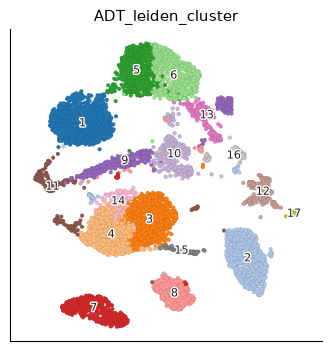

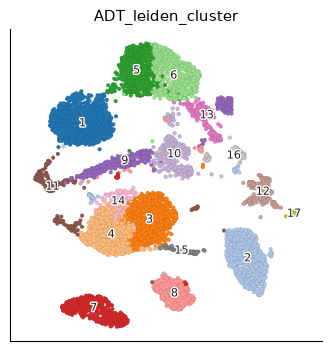

In [18]:
splt.embedding(
    ds,
    layout_key="ADT_UMAP",
    color_by="ADT_leiden_cluster",
    show=False,
).figure

/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


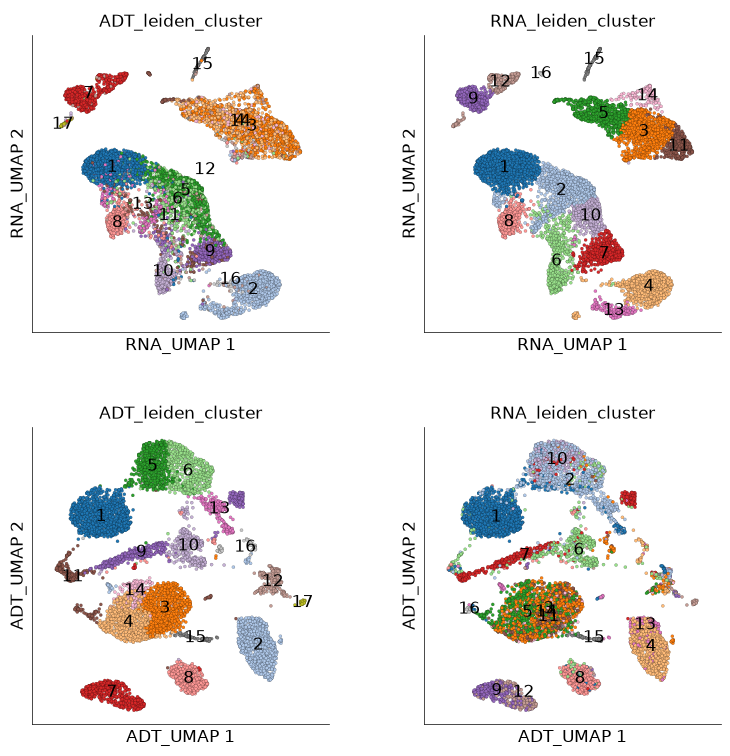

In [19]:
# UMAP on RNA and coloured with clusters calculated on ADT
ds.plot_layout(
    layout_key=["RNA_UMAP", "ADT_UMAP"],
    color_by=["ADT_leiden_cluster", "RNA_leiden_cluster"],
    cmap="tab20",
    width=4,
    height=4,
    n_columns=2,
    point_size=5,
    legend_onside=False,
)

In [20]:
import pandas as pd

df = pd.crosstab(
    ds.cells.fetch("RNA_leiden_cluster"), ds.cells.fetch("ADT_leiden_cluster")
)
df

col_0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
row_0,,,,,,,,,,,,,,,,,
1,1023,0,0,0,48,24,0,18,2,3,26,17,46,0,0,0,0
2,30,0,0,0,336,311,0,1,4,13,7,21,160,0,0,0,0
3,0,12,406,275,1,7,1,11,4,4,0,49,2,62,0,23,0
4,1,722,0,0,0,1,0,0,0,1,0,27,1,0,0,28,0
5,0,2,213,309,0,1,0,0,0,0,32,17,0,62,6,3,0
6,17,4,0,0,5,57,0,38,65,303,46,27,0,0,0,3,0
7,0,2,0,0,30,7,0,3,328,10,80,12,0,0,0,0,0
8,2,0,0,0,1,0,0,353,7,7,13,5,1,0,0,0,0
9,0,0,0,0,0,1,328,0,0,0,0,7,0,0,0,0,0


In [21]:
(100 * df.max() / df.sum()).sort_values(ascending=False)

col_0
17    100.000000
1      95.251397
10     86.819484
15     86.301370
8      82.284382
2      80.670391
9      79.036145
13     75.829384
7      63.076923
6      58.901515
5      58.232236
3      48.798077
16     45.161290
14     43.661972
4      42.620690
11     32.786885
12     20.762712
dtype: float64

/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


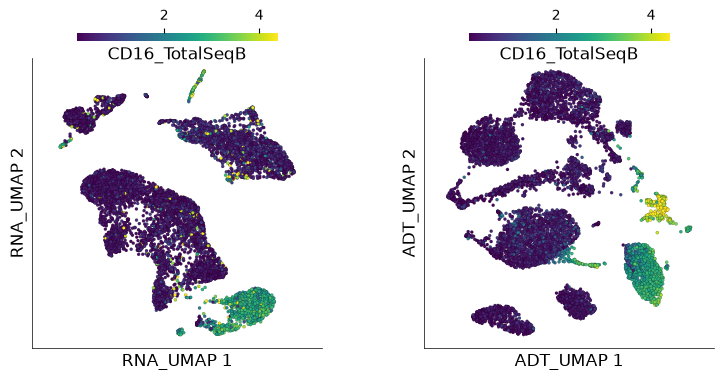

In [22]:
ds.plot_layout(
    layout_key=["RNA_UMAP", "ADT_UMAP"],
    color_by="CD16_TotalSeqB",
    from_assay="ADT",
    width=4,
    height=4,
    n_columns=2,
    point_size=5,
)

/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


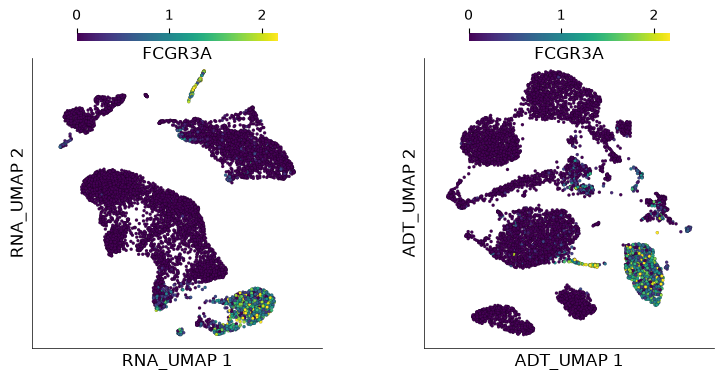

In [23]:
ds.plot_layout(
    layout_key=["RNA_UMAP", "ADT_UMAP"],
    color_by="FCGR3A",
    from_assay="RNA",
    width=4,
    height=4,
    n_columns=2,
    point_size=5,
)

In [24]:
ds.integrate_assays(
    assays=["RNA", "ADT"],
    label="RNA+ADT",
    method="snn",
)

In [25]:
ds.run_umap(
    integrated_graph="RNA+ADT", n_epochs=500, spread=5, min_dist=0.5, parallel=True
)

ds.run_leiden_clustering(integrated_graph="RNA+ADT", resolution=1.75)

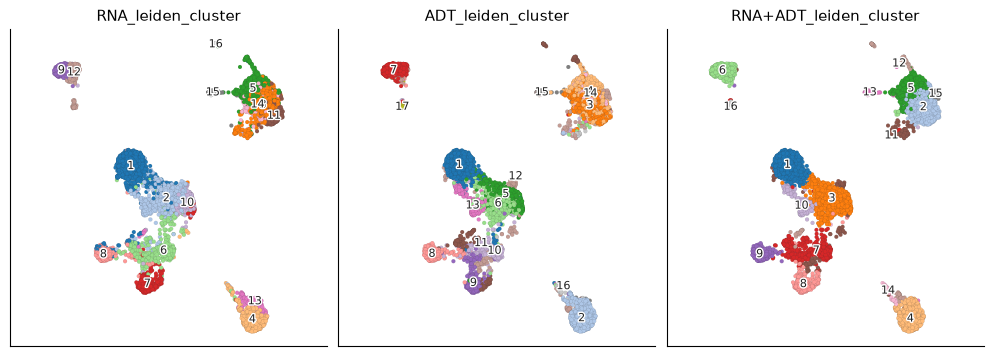

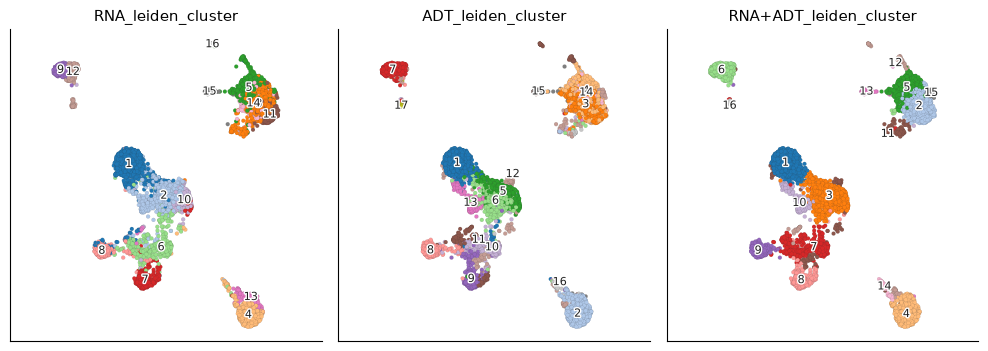

In [26]:
splt.embedding(
    ds,
    layout_key="RNA+ADT_UMAP",
    color_by=[
        "RNA_leiden_cluster",
        "ADT_leiden_cluster",
        "RNA+ADT_leiden_cluster",
    ],
    legend_loc="on_data",
    n_columns=3,
).figure

In [27]:
ds.cells.columns

['I',
 'ids',
 'names',
 'RNA_percentMito',
 'ADT_nFeatures',
 'RNA_tSNE2',
 'ADT_UMAP2',
 'RNA+ADT_UMAP1',
 'RNA_tSNE1',
 'ADT_UMAP1',
 'ADT_nCounts',
 'RNA_nFeatures',
 'RNA_percentRibo',
 'RNA+ADT_UMAP2',
 'RNA_nCounts',
 'RNA_cluster',
 'RNA+ADT_leiden_cluster',
 'RNA_leiden_cluster',
 'RNA_UMAP2',
 'RNA_UMAP1',
 'ADT_leiden_cluster']

In [28]:
ds.integrate_assays(assays=["RNA", "ADT"], label="RNA+ADT_wnn", method="wnn")

ds.run_umap(
    integrated_graph="RNA+ADT_wnn", n_epochs=500, spread=5, min_dist=0.5, parallel=True
)

ds.run_leiden_clustering(integrated_graph="RNA+ADT_wnn", resolution=1.75)

No dimension reduction was user for ADT data. Memory consumption will be high.



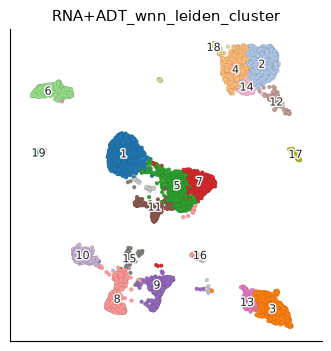

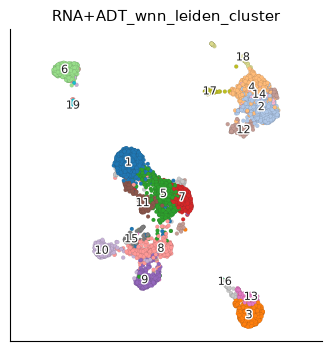

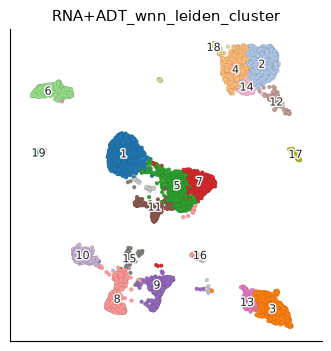

In [29]:
splt.embedding(
    ds,
    layout_key="RNA+ADT_UMAP",
    color_by="RNA+ADT_wnn_leiden_cluster",
    legend_loc="on_data",
).figure
splt.embedding(
    ds,
    layout_key="RNA+ADT_wnn_UMAP",
    color_by="RNA+ADT_wnn_leiden_cluster",
    legend_loc="on_data",
).figure